# Loan Approval Classification Modelling

This notebook builds and evaluates classification models for **Loan Approval Status** using the preprocessed classification dataset (`X_class`, `y_class`).

Models included:
- Logistic Regression
- Gaussian Naive Bayes
- K-Nearest Neighbors (k=5)

Evaluation included:
- Confusion Matrix
- Classification Report (precision, recall, f1-score)
- ROC Curve and AUC

Then the best model is selected based on Recall and AUC, and improved using GridSearchCV.

## 1. Import Libraries
Import all required packages for data handling, modelling, metrics, plotting, and tuning.

In [1]:
# Import warnings to suppress non-critical messages.
import warnings
# Ignore warnings to keep notebook outputs clean for screenshots.
warnings.filterwarnings("ignore")
# Import numpy for numerical operations.
import numpy as np
# Import pandas for tabular data processing.
import pandas as pd
# Import matplotlib for plotting.
import matplotlib.pyplot as plt
# Import seaborn for cleaner statistical visualizations.
import seaborn as sns
# Import train_test_split for splitting data into train and test sets.
from sklearn.model_selection import train_test_split
# Import StratifiedKFold for stratified cross-validation in tuning.
from sklearn.model_selection import StratifiedKFold
# Import GridSearchCV for hyperparameter tuning.
from sklearn.model_selection import GridSearchCV
# Import LabelEncoder for target encoding when needed.
from sklearn.preprocessing import LabelEncoder
# Import Logistic Regression classifier.
from sklearn.linear_model import LogisticRegression
# Import Gaussian Naive Bayes classifier.
from sklearn.naive_bayes import GaussianNB
# Import K-Nearest Neighbors classifier.
from sklearn.neighbors import KNeighborsClassifier
# Import confusion matrix metric.
from sklearn.metrics import confusion_matrix
# Import classification report metric.
from sklearn.metrics import classification_report
# Import ROC curve metric function.
from sklearn.metrics import roc_curve
# Import AUC score metric function.
from sklearn.metrics import roc_auc_score
# Set seaborn plotting style for better visuals.
sns.set_style("whitegrid")

## 2. Use Preprocessed Dataset (`X_class`, `y_class`)
This cell uses existing `X_class` and `y_class` if available. If they are not in memory, it recreates the same preprocessing pipeline from the original CSV file so modelling can run end-to-end.

In [2]:
# Check whether preprocessed classification datasets already exist in memory.
preprocessed_available = ("X_class" in globals()) and ("y_class" in globals())
# Enter fallback preprocessing when preprocessed variables are not available.
if not preprocessed_available:
    # Print status message to explain fallback execution.
    print("Preprocessed X_class and y_class not found in memory. Rebuilding from CSV...")
    # Define the dataset file path.
    csv_path = "loan_approval_data.csv"
    # Load the raw CSV dataset into a DataFrame.
    df = pd.read_csv(csv_path)
    # Define a helper function to normalize text for robust column matching.
    def normalize_name(text):
        # Convert text to lowercase and remove spaces and underscores.
        return str(text).strip().lower().replace(" ", "").replace("_", "")
    # Initialize a list to store ID-like columns.
    id_like_columns = []
    # Loop through every column in the raw dataset.
    for col in df.columns:
        # Normalize the current column name.
        normalized_col = normalize_name(col)
        # Check whether the normalized name indicates an ID column.
        if normalized_col == "id" or normalized_col.endswith("id") or normalized_col in {"loanid", "applicationid"}:
            # Add the column to the list of columns to drop.
            id_like_columns.append(col)
    # Drop all detected ID-like columns from the dataset.
    df = df.drop(columns=id_like_columns, errors="ignore")
    # Select numeric columns for mean imputation.
    numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    # Select categorical columns for mode imputation.
    categorical_columns = df.select_dtypes(exclude=[np.number]).columns.tolist()
    # Loop through all numeric columns for mean filling.
    for col in numeric_columns:
        # Compute the mean of the current numeric column.
        mean_value = df[col].mean()
        # Fill missing values in the numeric column with its mean.
        df[col] = df[col].fillna(mean_value)
    # Loop through all categorical columns for mode filling.
    for col in categorical_columns:
        # Compute the mode of the current categorical column.
        mode_value = df[col].mode(dropna=True)[0]
        # Fill missing values in the categorical column with its mode.
        df[col] = df[col].fillna(mode_value)
    # Define candidate names for the classification target column.
    class_target_candidates = ["loan_approval_status", "Loan Approval Status", "loan_status", "approved"]
    # Build a normalized-to-original dictionary for column lookup.
    normalized_to_original = {normalize_name(c): c for c in df.columns}
    # Initialize target column placeholder.
    class_target_col = None
    # Loop through candidate target names to find a match.
    for candidate in class_target_candidates:
        # Normalize the candidate target name.
        candidate_key = normalize_name(candidate)
        # Check whether this candidate exists in dataset columns.
        if candidate_key in normalized_to_original:
            # Save the matching original target column name.
            class_target_col = normalized_to_original[candidate_key]
            # Stop searching after first successful match.
            break
    # Raise an error if classification target is missing.
    if class_target_col is None:
        # Stop execution because required target is not available.
        raise ValueError("Could not find Loan Approval Status target column.")
    # Create feature matrix by dropping the target column.
    X_class = df.drop(columns=[class_target_col]).copy()
    # Create target vector from the target column.
    y_class = df[class_target_col].copy()
    # One-hot encode all categorical feature columns.
    X_class = pd.get_dummies(X_class, drop_first=False)
    # Check whether target labels are non-numeric.
    if not pd.api.types.is_numeric_dtype(y_class):
        # Create LabelEncoder object for target encoding.
        label_encoder = LabelEncoder()
        # Transform target labels into numeric classes.
        y_class = pd.Series(label_encoder.fit_transform(y_class), name=class_target_col)
# Print status message when preprocessed variables already exist.
if preprocessed_available:
    # Confirm that in-memory preprocessed variables are being reused.
    print("Using existing preprocessed X_class and y_class from memory.")
# Convert y_class to a pandas Series to ensure consistent indexing.
y_class = pd.Series(y_class).reset_index(drop=True)
# Convert X_class to a pandas DataFrame to ensure consistent structure.
X_class = pd.DataFrame(X_class).reset_index(drop=True)
# Print the final shape of feature matrix.
print("X_class shape:", X_class.shape)
# Print the final shape of target vector.
print("y_class shape:", y_class.shape)
# Print target class distribution for visibility.
print("\nTarget value counts:")
# Display counts of each class label.
display(y_class.value_counts(dropna=False))

Preprocessed X_class and y_class not found in memory. Rebuilding from CSV...
X_class shape: (58645, 20)
y_class shape: (58645,)

Target value counts:


loan_approval_status
0    50295
1     8350
Name: count, dtype: int64

## 3. Train-Test Split
Split data into train and test sets using:
- `test_size = 0.2`
- `stratify = y_class`
- `random_state = 42`

In [3]:
# Split features and target into train and test sets with stratification.
X_train, X_test, y_train, y_test = train_test_split(
    # Provide the feature matrix as split input.
    X_class,
    # Provide the target vector as split input.
    y_class,
    # Set test portion to 20 percent.
    test_size=0.2,
    # Stratify split to preserve class distribution.
    stratify=y_class,
    # Set random seed for reproducibility.
    random_state=42
)
# Print training feature shape.
print("X_train shape:", X_train.shape)
# Print testing feature shape.
print("X_test shape:", X_test.shape)
# Print training target shape.
print("y_train shape:", y_train.shape)
# Print testing target shape.
print("y_test shape:", y_test.shape)

X_train shape: (46916, 20)
X_test shape: (11729, 20)
y_train shape: (46916,)
y_test shape: (11729,)


## 4. Build and Train Three Classification Models
Train Logistic Regression, Gaussian Naive Bayes, and KNN (`k=5`) on the same training data.

In [4]:
# Create Logistic Regression model with stable settings.
log_reg_model = LogisticRegression(max_iter=2000, random_state=42)
# Create Gaussian Naive Bayes model.
gnb_model = GaussianNB()
# Create KNN model with k equals 5 as requested.
knn_model = KNeighborsClassifier(n_neighbors=5)
# Build a dictionary of model names and model objects.
models = {
    # Add Logistic Regression entry.
    "Logistic Regression": log_reg_model,
    # Add Gaussian Naive Bayes entry.
    "Gaussian Naive Bayes": gnb_model,
    # Add K-Nearest Neighbors entry.
    "K-Nearest Neighbors": knn_model
}
# Loop through each model for training on the same training dataset.
for model_name, model_obj in models.items():
    # Train the current model using training features and target labels.
    model_obj.fit(X_train, y_train)
    # Print confirmation that the model has finished training.
    print(f"Trained: {model_name}")

Trained: Logistic Regression
Trained: Gaussian Naive Bayes
Trained: K-Nearest Neighbors


## 5. Evaluate Models (Confusion Matrix, Report, ROC, AUC)
For each model, this section displays:
- Confusion Matrix
- Classification Report
- ROC Curve
- AUC Score

It also stores Recall and AUC values for model comparison.


Model: Logistic Regression
Confusion Matrix:


,Pred 0,Pred 1
Actual 0,10032,27
Actual 1,1,1669


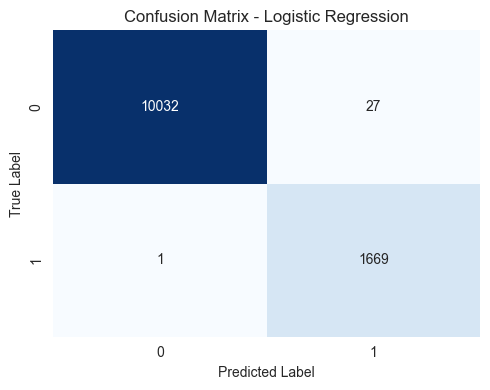

Classification Report:


,precision,recall,f1-score,support
0,0.9999,0.9973,0.9986,10059.0000
1,0.9841,0.9994,0.9917,1670.0000
accuracy,0.9976,0.9976,0.9976,0.9976
macro avg,0.9920,0.9984,0.9951,11729.0000
weighted avg,0.9976,0.9976,0.9976,11729.0000


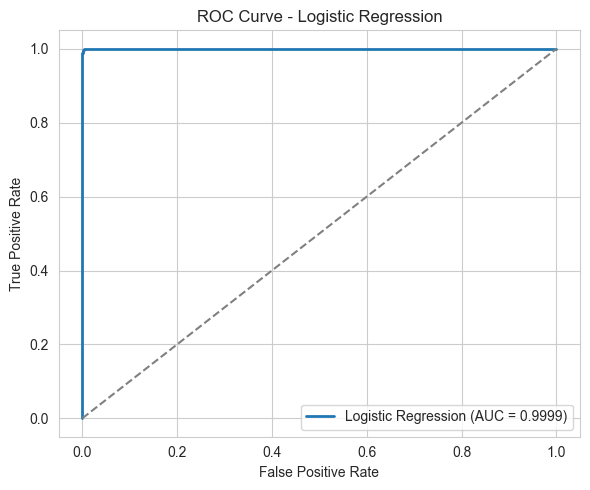


Model: Gaussian Naive Bayes
Confusion Matrix:


,Pred 0,Pred 1
Actual 0,10059,0
Actual 1,3,1667


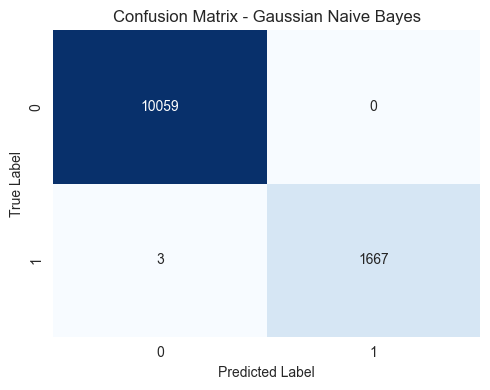

Classification Report:


,precision,recall,f1-score,support
0,0.9997,1.0000,0.9999,10059.0000
1,1.0000,0.9982,0.9991,1670.0000
accuracy,0.9997,0.9997,0.9997,0.9997
macro avg,0.9999,0.9991,0.9995,11729.0000
weighted avg,0.9997,0.9997,0.9997,11729.0000


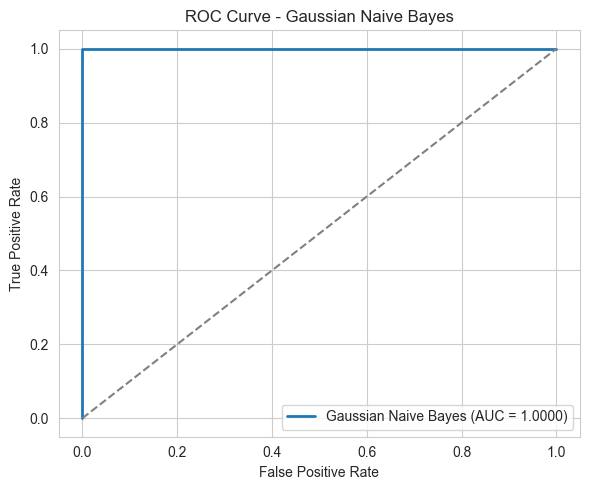


Model: K-Nearest Neighbors
Confusion Matrix:


,Pred 0,Pred 1
Actual 0,10049,10
Actual 1,1,1669


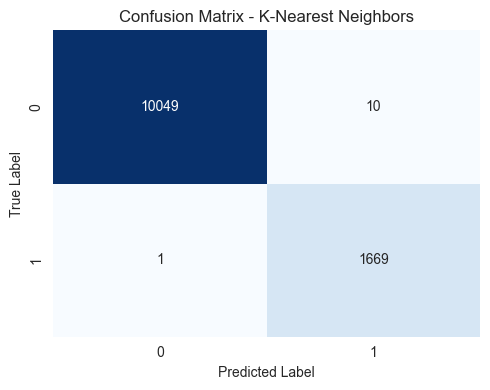

Classification Report:


,precision,recall,f1-score,support
0,0.9999,0.9990,0.9995,10059.0000
1,0.9940,0.9994,0.9967,1670.0000
accuracy,0.9991,0.9991,0.9991,0.9991
macro avg,0.9970,0.9992,0.9981,11729.0000
weighted avg,0.9991,0.9991,0.9991,11729.0000


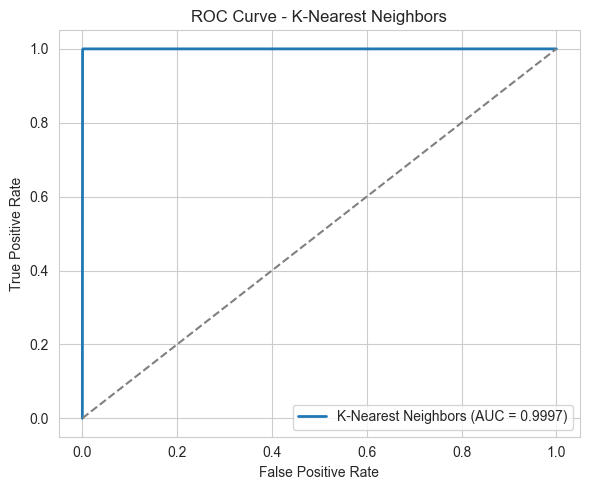

In [5]:
# Identify unique target classes from test labels.
unique_classes = np.sort(np.unique(y_test))
# Stop execution if the task is not binary classification.
if len(unique_classes) != 2:
    # Raise an error because ROC/AUC setup below is binary-specific.
    raise ValueError("This notebook currently expects a binary target for ROC/AUC comparison.")
# Define positive class as the larger sorted class label.
positive_class = unique_classes[-1]
# Create an empty list to store evaluation summaries for all models.
evaluation_rows = []
# Loop through each trained model for evaluation.
for model_name, model_obj in models.items():
    # Print a separator line to make outputs screenshot-friendly.
    print("\n" + "=" * 80)
    # Print the current model name as heading.
    print(f"Model: {model_name}")
    # Print another separator line.
    print("=" * 80)
    # Predict class labels for test features.
    y_pred = model_obj.predict(X_test)
    # Predict positive class probabilities for ROC and AUC.
    y_prob = model_obj.predict_proba(X_test)[:, 1]
    # Compute confusion matrix for current model.
    cm = confusion_matrix(y_test, y_pred)
    # Print label for confusion matrix section.
    print("Confusion Matrix:")
    # Display confusion matrix values as a DataFrame.
    display(pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))
    # Plot confusion matrix as a heatmap for visual clarity.
    plt.figure(figsize=(5, 4))
    # Draw heatmap using confusion matrix values.
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    # Set confusion matrix plot title.
    plt.title(f"Confusion Matrix - {model_name}")
    # Set x-axis label for predicted class.
    plt.xlabel("Predicted Label")
    # Set y-axis label for actual class.
    plt.ylabel("True Label")
    # Adjust layout to avoid clipping.
    plt.tight_layout()
    # Show confusion matrix heatmap.
    plt.show()
    # Compute classification report as a dictionary for extraction and display.
    report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    # Print label for classification report section.
    print("Classification Report:")
    # Display classification report as a DataFrame with rounded values.
    display(pd.DataFrame(report_dict).transpose().round(4))
    # Compute false-positive rate and true-positive rate for ROC curve.
    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=positive_class)
    # Compute AUC score for current model.
    auc_value = roc_auc_score(y_test, y_prob)
    # Plot ROC curve for current model.
    plt.figure(figsize=(6, 5))
    # Draw ROC line for the current model.
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_value:.4f})", linewidth=2)
    # Draw reference diagonal line representing random classifier.
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    # Set ROC chart title.
    plt.title(f"ROC Curve - {model_name}")
    # Set x-axis label for false positive rate.
    plt.xlabel("False Positive Rate")
    # Set y-axis label for true positive rate.
    plt.ylabel("True Positive Rate")
    # Place legend in lower right corner.
    plt.legend(loc="lower right")
    # Adjust layout to avoid clipping.
    plt.tight_layout()
    # Show ROC curve plot.
    plt.show()
    # Extract recall for positive class from classification report.
    positive_recall = report_dict[str(int(positive_class))]["recall"] if str(int(positive_class)) in report_dict else report_dict[str(positive_class)]["recall"]
    # Append model metrics to summary list.
    evaluation_rows.append({
        # Save model name in summary row.
        "Model": model_name,
        # Save recall score for positive class.
        "Recall": positive_recall,
        # Save AUC score for comparison.
        "AUC": auc_value
    })

## 6. Compare Models by Recall and AUC
This table compares all models based on Recall and AUC (important for identifying risky clients).

In [6]:
# Convert evaluation rows into a DataFrame for comparison.
comparison_df = pd.DataFrame(evaluation_rows)
# Sort models by recall first and AUC second in descending order.
comparison_df = comparison_df.sort_values(by=["Recall", "AUC"], ascending=False).reset_index(drop=True)
# Print heading for comparison table.
print("Model Comparison (sorted by Recall then AUC):")
# Display rounded comparison table for screenshot clarity.
display(comparison_df.round(4))
# Select the top-ranked model name as best model.
best_model_name = comparison_df.loc[0, "Model"]
# Retrieve the trained best model object from model dictionary.
best_model_before_tuning = models[best_model_name]
# Print selected best model for tuning step.
print(f"Best model selected for tuning: {best_model_name}")

Model Comparison (sorted by Recall then AUC):


,Model,Recall,AUC
0,Logistic Regression,0.9994,0.9999
1,K-Nearest Neighbors,0.9994,0.9997
2,Gaussian Naive Bayes,0.9982,1.0000


Best model selected for tuning: Logistic Regression


## 7. Hyperparameter Tuning with GridSearchCV
Tune the best model from the previous step.

Examples:
- KNN: tune `n_neighbors`
- Logistic Regression: tune `C`

The grid is selected automatically based on whichever model ranked best.

In [7]:
# Create stratified cross-validation strategy for fair tuning.
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Initialize placeholders for estimator and parameter grid.
estimator_for_tuning = None
param_grid = None
# Select tuning configuration for Logistic Regression.
if best_model_name == "Logistic Regression":
    # Build Logistic Regression estimator for GridSearchCV.
    estimator_for_tuning = LogisticRegression(max_iter=3000, random_state=42)
    # Define C search space for Logistic Regression.
    param_grid = {"C": [0.01, 0.1, 1, 10, 100]}
# Select tuning configuration for K-Nearest Neighbors.
elif best_model_name == "K-Nearest Neighbors":
    # Build KNN estimator for GridSearchCV.
    estimator_for_tuning = KNeighborsClassifier()
    # Define search space for KNN hyperparameters.
    param_grid = {
        # Tune number of neighbors.
        "n_neighbors": [3, 5, 7, 9, 11, 15],
        # Tune weighting strategy for neighbors.
        "weights": ["uniform", "distance"],
        # Tune distance metric parameter p.
        "p": [1, 2]
    }
# Select tuning configuration for Gaussian Naive Bayes.
elif best_model_name == "Gaussian Naive Bayes":
    # Build GaussianNB estimator for GridSearchCV.
    estimator_for_tuning = GaussianNB()
    # Define smoothing search space for GaussianNB.
    param_grid = {"var_smoothing": np.logspace(-12, -7, 6)}
# Raise error if best model name does not match expected models.
else:
    # Stop execution because tuning configuration is missing.
    raise ValueError("Unsupported best model name for tuning.")
# Print tuning grid to make search space visible in output.
print("Parameter grid used for tuning:")
# Display parameter grid dictionary.
display(param_grid)
# Build GridSearchCV object using recall as optimization metric.
grid_search = GridSearchCV(
    # Use selected estimator as model to tune.
    estimator=estimator_for_tuning,
    # Use selected parameter grid.
    param_grid=param_grid,
    # Optimize for recall to prioritize risky-client rejection.
    scoring="recall",
    # Use stratified cross-validation strategy.
    cv=cv_strategy,
    # Use all available CPU cores.
    n_jobs=-1
)
# Fit grid search on training data.
grid_search.fit(X_train, y_train)
# Extract best tuned model from GridSearchCV results.
best_model_after_tuning = grid_search.best_estimator_
# Print best parameters found by GridSearchCV.
print("Best Parameters:")
# Display best parameter dictionary.
display(grid_search.best_params_)

Parameter grid used for tuning:


{'C': [0.01, 0.1, 1, 10, 100]}

Best Parameters:


{'C': 0.01}

## 8. Performance Before vs After Tuning
Evaluate the selected model on test data before and after tuning, then compare Recall and AUC.

Performance Comparison (Best Model):


,Metric,Before Tuning,After Tuning
0,Recall,0.9994,0.9994
1,AUC,0.9999,0.9999



Classification Report Before Tuning:


,precision,recall,f1-score,support
0,0.9999,0.9973,0.9986,10059.0000
1,0.9841,0.9994,0.9917,1670.0000
accuracy,0.9976,0.9976,0.9976,0.9976
macro avg,0.9920,0.9984,0.9951,11729.0000
weighted avg,0.9976,0.9976,0.9976,11729.0000


Classification Report After Tuning:


,precision,recall,f1-score,support
0,0.9999,0.9971,0.9985,10059.0000
1,0.9829,0.9994,0.9911,1670.0000
accuracy,0.9974,0.9974,0.9974,0.9974
macro avg,0.9914,0.9983,0.9948,11729.0000
weighted avg,0.9975,0.9974,0.9975,11729.0000


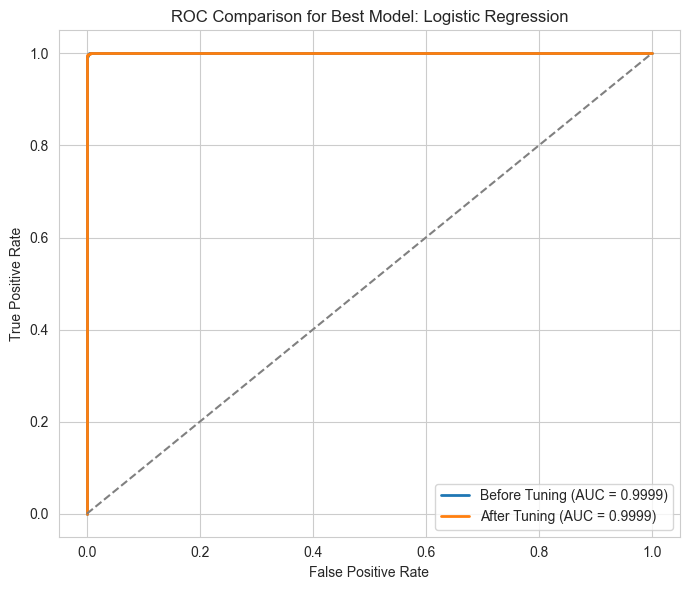

In [8]:
# Predict labels using the best model before tuning.
y_pred_before = best_model_before_tuning.predict(X_test)
# Predict positive probabilities using the best model before tuning.
y_prob_before = best_model_before_tuning.predict_proba(X_test)[:, 1]
# Compute report dictionary before tuning.
report_before = classification_report(y_test, y_pred_before, output_dict=True, zero_division=0)
# Compute AUC before tuning.
auc_before = roc_auc_score(y_test, y_prob_before)
# Extract recall before tuning for positive class.
recall_before = report_before[str(int(positive_class))]["recall"] if str(int(positive_class)) in report_before else report_before[str(positive_class)]["recall"]
# Predict labels using the tuned best model.
y_pred_after = best_model_after_tuning.predict(X_test)
# Predict positive probabilities using the tuned best model.
y_prob_after = best_model_after_tuning.predict_proba(X_test)[:, 1]
# Compute report dictionary after tuning.
report_after = classification_report(y_test, y_pred_after, output_dict=True, zero_division=0)
# Compute AUC after tuning.
auc_after = roc_auc_score(y_test, y_prob_after)
# Extract recall after tuning for positive class.
recall_after = report_after[str(int(positive_class))]["recall"] if str(int(positive_class)) in report_after else report_after[str(positive_class)]["recall"]
# Build before-vs-after performance table.
before_after_df = pd.DataFrame({
    # Add metric names as table index labels.
    "Metric": ["Recall", "AUC"],
    # Add values from untuned model.
    "Before Tuning": [recall_before, auc_before],
    # Add values from tuned model.
    "After Tuning": [recall_after, auc_after]
})
# Print heading for before-after comparison table.
print("Performance Comparison (Best Model):")
# Display rounded before-after table for screenshots.
display(before_after_df.round(4))
# Print detailed classification report before tuning.
print("\nClassification Report Before Tuning:")
# Display report before tuning as DataFrame.
display(pd.DataFrame(report_before).transpose().round(4))
# Print detailed classification report after tuning.
print("Classification Report After Tuning:")
# Display report after tuning as DataFrame.
display(pd.DataFrame(report_after).transpose().round(4))
# Compute ROC points for untuned model.
fpr_before, tpr_before, _ = roc_curve(y_test, y_prob_before, pos_label=positive_class)
# Compute ROC points for tuned model.
fpr_after, tpr_after, _ = roc_curve(y_test, y_prob_after, pos_label=positive_class)
# Create a ROC comparison plot.
plt.figure(figsize=(7, 6))
# Draw ROC curve before tuning.
plt.plot(fpr_before, tpr_before, linewidth=2, label=f"Before Tuning (AUC = {auc_before:.4f})")
# Draw ROC curve after tuning.
plt.plot(fpr_after, tpr_after, linewidth=2, label=f"After Tuning (AUC = {auc_after:.4f})")
# Draw random baseline diagonal line.
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
# Set plot title.
plt.title(f"ROC Comparison for Best Model: {best_model_name}")
# Set x-axis label.
plt.xlabel("False Positive Rate")
# Set y-axis label.
plt.ylabel("True Positive Rate")
# Show legend with AUC values.
plt.legend(loc="lower right")
# Apply tight layout to avoid clipping.
plt.tight_layout()
# Display the ROC comparison plot.
plt.show()

## 9. Final Notes
This notebook has:
- Trained 3 classification models on the same split
- Evaluated each with Confusion Matrix, Classification Report, ROC, and AUC
- Compared models using Recall and AUC
- Tuned the best model with GridSearchCV
- Reported performance before and after tuning

All outputs are displayed inline for easy coursework screenshots.